In [21]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [23]:
# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [25]:
# Load the data
player_stats = pd.read_csv('player_statistics.csv')
item_spend = pd.read_csv('item_spend.csv')

print("=" * 60)
print("DATA OVERVIEW")
print("=" * 60)
print(f"\nPlayer Statistics: {player_stats.shape[0]:,} rows, {player_stats.shape[1]} columns")
print(f"Item Spend: {item_spend.shape[0]:,} rows, {item_spend.shape[1]} columns")
print(f"Unique Players: {player_stats['account_id'].nunique():,}")

DATA OVERVIEW

Player Statistics: 246,137 rows, 10 columns
Item Spend: 155,750 rows, 7 columns
Unique Players: 9,476


In [27]:
# ============================================================================
# PART 1: AGGREGATE PLAYER-LEVEL METRICS
# ============================================================================

print("\n" + "=" * 60)
print("CREATING PLAYER-LEVEL AGGREGATES")
print("=" * 60)

# Aggregate player statistics to player level
player_profiles = player_stats.groupby('account_id').agg({
    'platform_id': 'first',
    'daily_playtime': 'sum',  # Total playtime across all days
    'evc_balance': 'last',    # Final earned balance
    'pvc_balance': 'last',    # Final paid balance
    'char_rank': 'last',      # Final rank
    'ltd_days_played': 'last',
    'days_since_first': 'max'
}).reset_index()

# Aggregate spending to player level
player_spending = item_spend.groupby('account_id').agg({
    'money_spent': 'sum'
}).reset_index()
player_spending.columns = ['account_id', 'total_spent']

# Merge spending data
player_profiles = player_profiles.merge(
    player_spending, 
    on='account_id', 
    how='left'
)
player_profiles['total_spent'] = player_profiles['total_spent'].fillna(0)

# Create additional metrics
player_profiles['total_balance'] = player_profiles['evc_balance'] + player_profiles['pvc_balance']
player_profiles['pvc_ratio'] = player_profiles['pvc_balance'] / (player_profiles['total_balance'] + 1)
player_profiles['is_payer'] = (player_profiles['pvc_balance'] > 0).astype(int)
player_profiles['spend_per_hour'] = player_profiles['total_spent'] / (player_profiles['daily_playtime'] + 0.1)

print(f"\nPlayer profiles created for {len(player_profiles):,} players")
print("\nSample player profile:")
print(player_profiles.head())



CREATING PLAYER-LEVEL AGGREGATES

Player profiles created for 9,476 players

Sample player profile:
   account_id platform_id  daily_playtime    evc_balance  pvc_balance  \
0           0        XBOX       10.101785  215232.371316          0.0   
1           1         PS4       13.870489   37081.564412          0.0   
2           2        XBOX       17.796335   22061.810082          0.0   
3           3        XBOX       22.613138   46616.295076          0.0   
4           4        XBOX       14.678832   12091.466326          0.0   

   char_rank  ltd_days_played  days_since_first   total_spent  total_balance  \
0       36.0            189.0               564  1.045527e+06  215232.371316   
1       39.0            135.0              1332  3.484761e+05   37081.564412   
2       14.0             57.0               291  1.837875e+06   22061.810082   
3        6.0              3.0              1874  3.129912e+06   46616.295076   
4       98.0            560.0               890  6.687334e+0

In [29]:
# ============================================================================
# PART 2: PLAYTIME vs SPENDING CORRELATION
# ============================================================================

print("\n" + "=" * 60)
print("ANALYSIS 1: PLAYTIME vs SPENDING CORRELATION")
print("=" * 60)

# Filter to spenders only for correlation
spenders = player_profiles[player_profiles['total_spent'] > 0].copy()

correlation = spenders['daily_playtime'].corr(spenders['total_spent'])
print(f"\nCorrelation between total playtime and spending: {correlation:.3f}")

# Calculate correlation by playtime quartiles
player_profiles['playtime_quartile'] = pd.qcut(
    player_profiles['daily_playtime'], 
    q=4, 
    labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']
)

playtime_analysis = player_profiles.groupby('playtime_quartile', observed=False).agg({
    'total_spent': ['mean', 'median', 'sum'],
    'is_payer': 'mean',
    'daily_playtime': 'mean',
    'account_id': 'count'
}).round(2)

print("\n--- Spending by Playtime Quartile ---")
print(playtime_analysis)


ANALYSIS 1: PLAYTIME vs SPENDING CORRELATION

Correlation between total playtime and spending: 0.237

--- Spending by Playtime Quartile ---
                  total_spent                           is_payer  \
                         mean      median           sum     mean   
playtime_quartile                                                  
Q1 (Low)           1175248.46   480725.45  2.784164e+09     0.04   
Q2                 2000971.06   802863.36  4.740300e+09     0.03   
Q3                 3545800.72  1326283.61  8.400002e+09     0.03   
Q4 (High)          6934291.33  2938708.57  1.642734e+10     0.02   

                  daily_playtime account_id  
                            mean      count  
playtime_quartile                            
Q1 (Low)                    3.49       2369  
Q2                          7.87       2369  
Q3                         14.69       2369  
Q4 (High)                  45.00       2369  


In [31]:
# ============================================================================
# PART 3: EARNED vs PAID CURRENCY ANALYSIS
# ============================================================================

print("\n" + "=" * 60)
print("ANALYSIS 2: EARNED vs PAID CURRENCY")
print("=" * 60)

print(f"\nPlayers with paid currency: {player_profiles['is_payer'].sum():,} "
      f"({player_profiles['is_payer'].mean()*100:.1f}%)")

currency_stats = player_profiles.agg({
    'evc_balance': ['mean', 'median', 'sum'],
    'pvc_balance': ['mean', 'median', 'sum'],
    'total_balance': ['mean', 'median', 'sum']
}).round(2)

print("\n--- Currency Balance Statistics ---")
print(currency_stats)

# Compare payers vs non-payers
payer_comparison = player_profiles.groupby('is_payer').agg({
    'daily_playtime': 'mean',
    'total_spent': 'mean',
    'evc_balance': 'mean',
    'pvc_balance': 'mean',
    'char_rank': 'mean',
    'ltd_days_played': 'mean',
    'account_id': 'count'
}).round(2)
payer_comparison.index = ['Non-Payers', 'Payers']

print("\n--- Payers vs Non-Payers ---")
print(payer_comparison)


ANALYSIS 2: EARNED vs PAID CURRENCY

Players with paid currency: 258 (2.7%)

--- Currency Balance Statistics ---
         evc_balance   pvc_balance  total_balance
mean    3.707271e+08  1.873055e+04   3.707458e+08
median  2.160116e+05  0.000000e+00   2.276285e+05
sum     3.513010e+12  1.774907e+08   3.513188e+12

--- Payers vs Non-Payers ---
            daily_playtime  total_spent   evc_balance  pvc_balance  char_rank  \
Non-Payers           17.90   3432593.43  3.810872e+08         0.00      56.17   
Payers               12.99   2752542.22  5.757074e+05    687948.54      32.44   

            ltd_days_played  account_id  
Non-Payers           235.41        9218  
Payers               176.22         258  



GENERATING VISUALIZATIONS


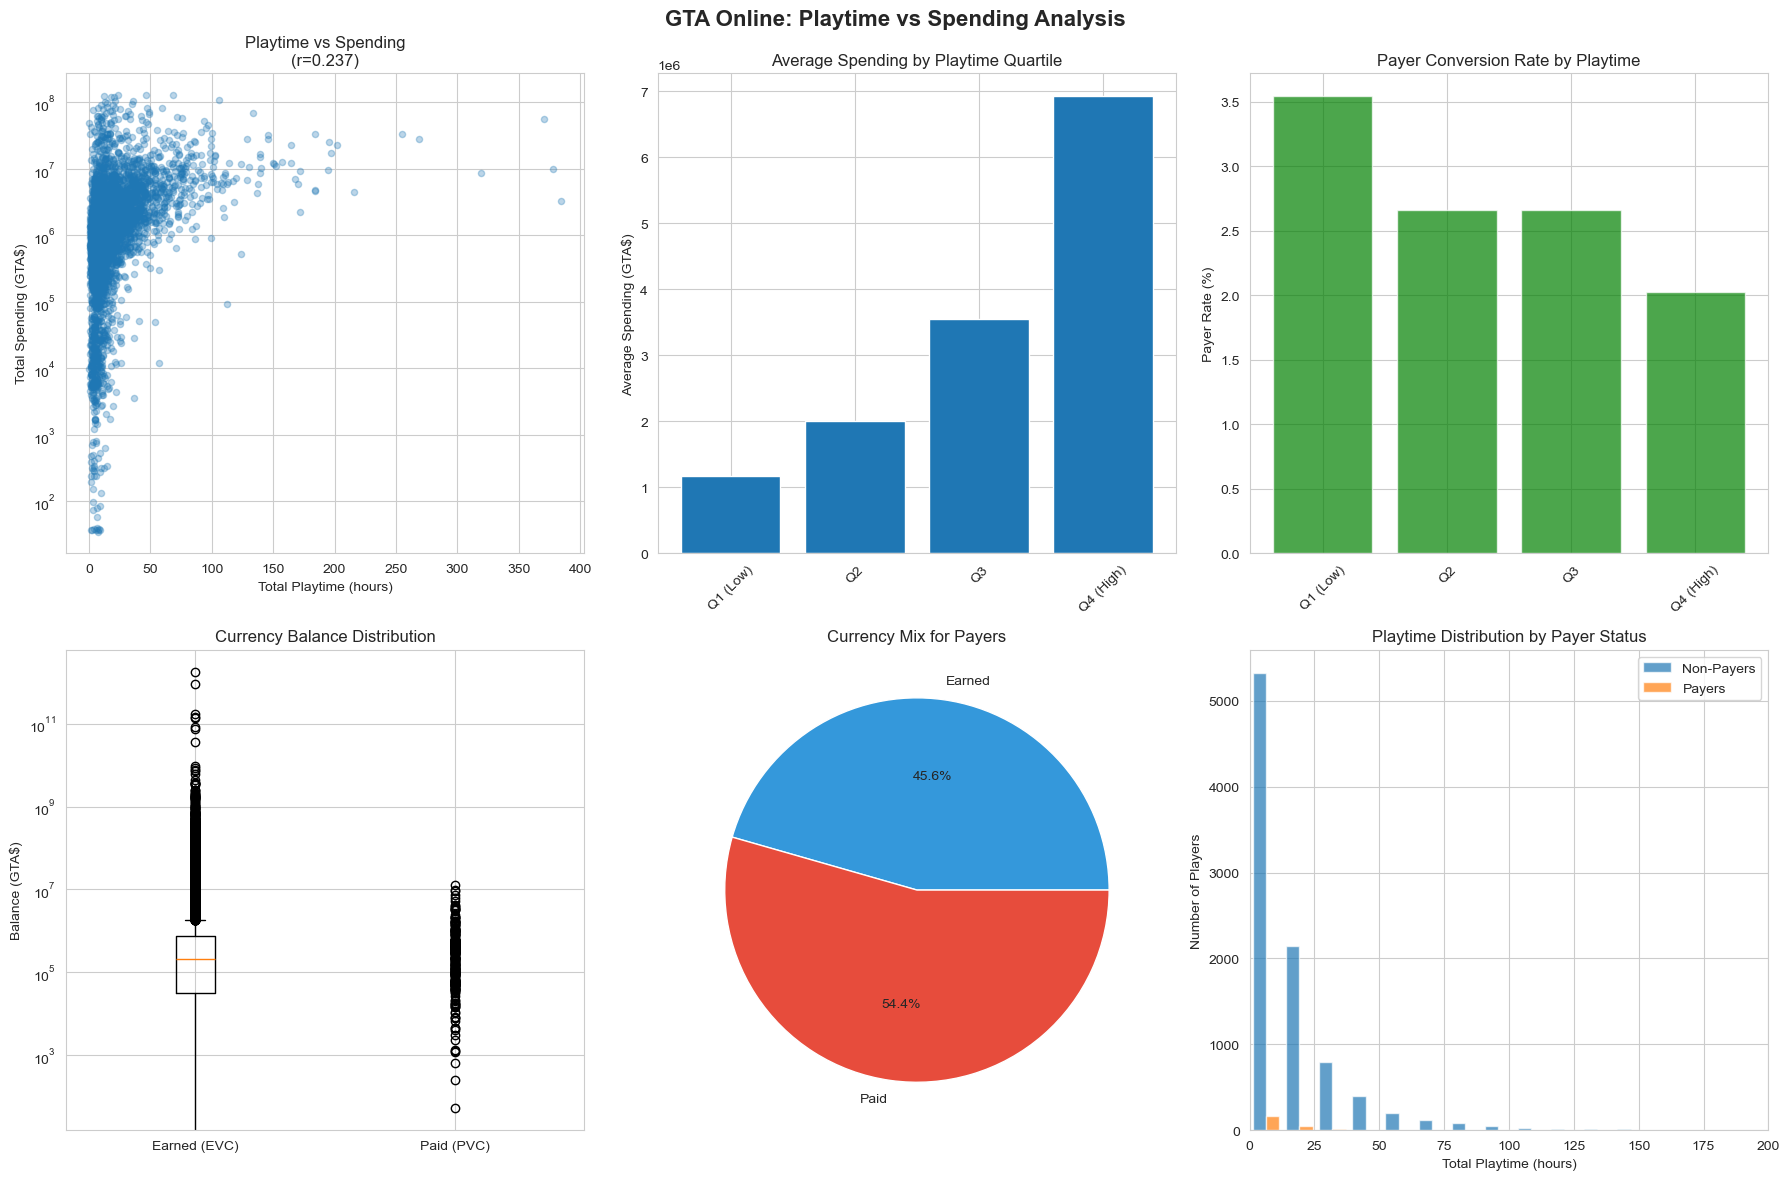


Visualizations complete!


In [33]:
# ============================================================================
# PART 4: VISUALIZATIONS
# ============================================================================

print("\n" + "=" * 60)
print("GENERATING VISUALIZATIONS")
print("=" * 60)

# Create a comprehensive dashboard
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('GTA Online: Playtime vs Spending Analysis', fontsize=16, fontweight='bold')

# 1. Playtime vs Spending Scatter
ax1 = axes[0, 0]
spenders_sample = spenders.sample(min(5000, len(spenders)))
ax1.scatter(spenders_sample['daily_playtime'], spenders_sample['total_spent'], 
            alpha=0.3, s=20)
ax1.set_xlabel('Total Playtime (hours)')
ax1.set_ylabel('Total Spending (GTA$)')
ax1.set_title(f'Playtime vs Spending\n(r={correlation:.3f})')
ax1.set_yscale('log')

# 2. Spending by Playtime Quartile
ax2 = axes[0, 1]
quartile_means = player_profiles.groupby('playtime_quartile')['total_spent'].mean()
ax2.bar(range(len(quartile_means)), quartile_means.values)
ax2.set_xticks(range(len(quartile_means)))
ax2.set_xticklabels(quartile_means.index, rotation=45)
ax2.set_ylabel('Average Spending (GTA$)')
ax2.set_title('Average Spending by Playtime Quartile')

# 3. Payer Rate by Playtime Quartile
ax3 = axes[0, 2]
payer_rate = player_profiles.groupby('playtime_quartile')['is_payer'].mean() * 100
ax3.bar(range(len(payer_rate)), payer_rate.values, color='green', alpha=0.7)
ax3.set_xticks(range(len(payer_rate)))
ax3.set_xticklabels(payer_rate.index, rotation=45)
ax3.set_ylabel('Payer Rate (%)')
ax3.set_title('Payer Conversion Rate by Playtime')

# 4. Currency Balance Distribution
ax4 = axes[1, 0]
balance_data = [
    player_profiles['evc_balance'].values,
    player_profiles['pvc_balance'].values
]
ax4.boxplot(balance_data, labels=['Earned (EVC)', 'Paid (PVC)'])
ax4.set_ylabel('Balance (GTA$)')
ax4.set_title('Currency Balance Distribution')
ax4.set_yscale('log')

# 5. Currency Mix for Payers
ax5 = axes[1, 1]
payers_only = player_profiles[player_profiles['is_payer'] == 1]
currency_mix = payers_only[['evc_balance', 'pvc_balance']].mean()
ax5.pie(currency_mix.values, labels=['Earned', 'Paid'], autopct='%1.1f%%',
        colors=['#3498db', '#e74c3c'])
ax5.set_title('Currency Mix for Payers')

# 6. Playtime Distribution: Payers vs Non-Payers
ax6 = axes[1, 2]
payers_playtime = player_profiles[player_profiles['is_payer'] == 1]['daily_playtime']
non_payers_playtime = player_profiles[player_profiles['is_payer'] == 0]['daily_playtime']
ax6.hist([non_payers_playtime, payers_playtime], bins=50, 
         label=['Non-Payers', 'Payers'], alpha=0.7)
ax6.set_xlabel('Total Playtime (hours)')
ax6.set_ylabel('Number of Players')
ax6.set_title('Playtime Distribution by Payer Status')
ax6.legend()
ax6.set_xlim(0, 200)

plt.tight_layout()
plt.show()

print("\nVisualizations complete!")

In [35]:
# ============================================================================
# PART 5: KEY INSIGHTS SUMMARY
# ============================================================================

print("\n" + "=" * 60)
print("KEY INSIGHTS")
print("=" * 60)

print("\n1. PLAYTIME-SPENDING RELATIONSHIP:")
print(f"   - Correlation coefficient: {correlation:.3f}")
print(f"   - Top quartile players spend {playtime_analysis.loc['Q4 (High)', ('total_spent', 'mean')]:.0f} GTA$ on average")
print(f"   - Bottom quartile players spend {playtime_analysis.loc['Q1 (Low)', ('total_spent', 'mean')]:.0f} GTA$ on average")

print("\n2. CURRENCY USAGE:")
print(f"   - {player_profiles['is_payer'].mean()*100:.1f}% of players use paid currency")
print(f"   - Payers have {payer_comparison.loc['Payers', 'evc_balance']:.0f} earned GTA$ on average")
print(f"   - Payers have {payer_comparison.loc['Payers', 'pvc_balance']:.0f} paid GTA$ on average")
print(f"   - Payers play {payer_comparison.loc['Payers', 'daily_playtime']:.1f} hours vs "
      f"{payer_comparison.loc['Non-Payers', 'daily_playtime']:.1f} hours for non-payers")

# Save the processed data for further analysis
player_profiles.to_csv('player_profiles_analyzed.csv', index=False)
print("\n✓ Analysis complete! Processed data saved to 'player_profiles_analyzed.csv'")


KEY INSIGHTS

1. PLAYTIME-SPENDING RELATIONSHIP:
   - Correlation coefficient: 0.237
   - Top quartile players spend 6934291 GTA$ on average
   - Bottom quartile players spend 1175248 GTA$ on average

2. CURRENCY USAGE:
   - 2.7% of players use paid currency
   - Payers have 575707 earned GTA$ on average
   - Payers have 687949 paid GTA$ on average
   - Payers play 13.0 hours vs 17.9 hours for non-payers

✓ Analysis complete! Processed data saved to 'player_profiles_analyzed.csv'
